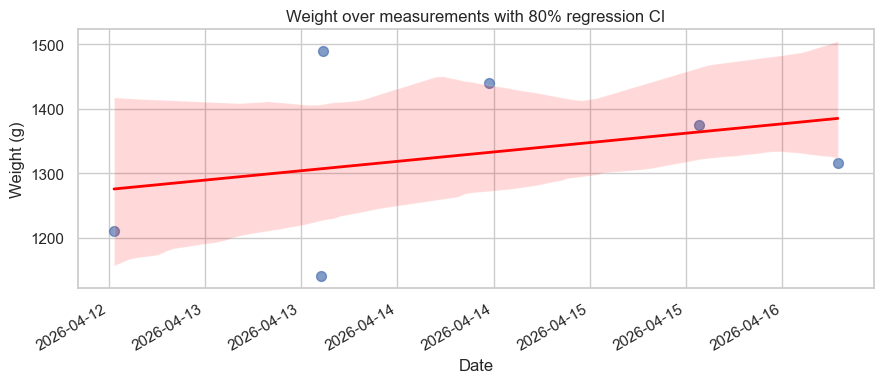

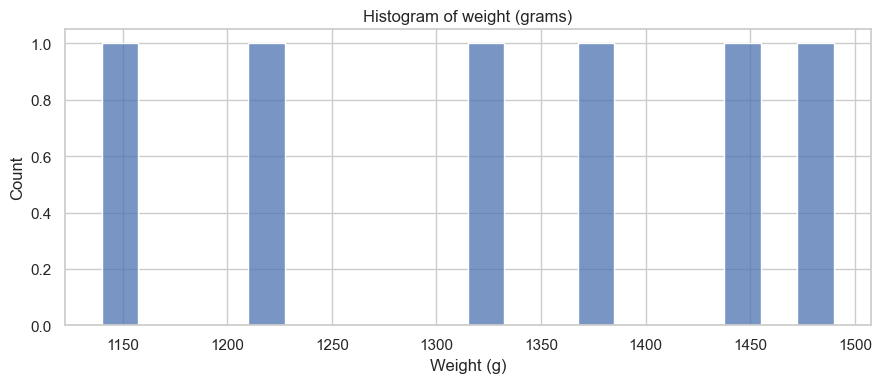

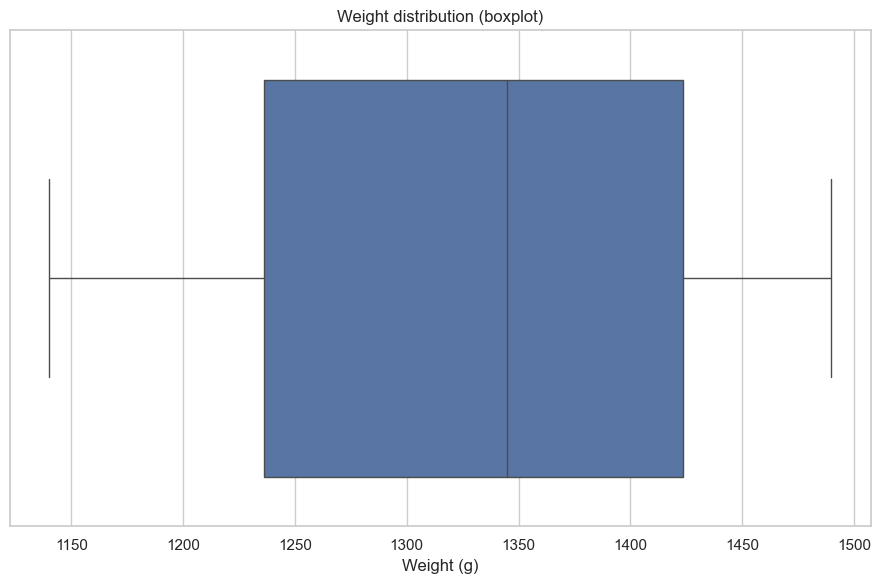

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sns.set(style="whitegrid")

# Read CSV 
df = pd.read_csv("measurements.csv")

df["time_dt"] = pd.to_datetime(
    df["time"],
    format="%Y-%m-%dT%H:%M:%S",
    errors="coerce"
)

#  Drop the rows where time could not be parsed
df = df.dropna(subset=["time_dt", "weight_grams"]).copy()

# Convert datetime to matplotlib numeric date
df["time_num"] = mdates.date2num(df["time_dt"])

# Sort by timestamp
df = df.sort_values("time_num")

# Save enriched DataFrame for future reference
df.to_csv("measurements_enriched.csv", index=False)
df.to_pickle("measurements_enriched.pkl")


# Plot weight vs time with regression line and 80% CI
fig, ax = plt.subplots(figsize=(9, 4))

sns.regplot(
    data=df,
    x="time_num",
    y="weight_grams",
    ci=80,
    ax=ax,
    scatter_kws={"alpha": 0.7, "s": 50},
    line_kws={"color": "red", "linewidth": 2}
)

# Format x-axis to show human readable dates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()

ax.set_title("Weight over measurements with 80% regression CI")
ax.set_xlabel("Date")
ax.set_ylabel("Weight (g)")

plt.tight_layout()
plt.show()

# Histogram of weight
plt.figure(figsize=(9, 4))
sns.histplot(
    data=df,
    x="weight_grams",
    bins=20,
    kde=False
)
plt.title("Histogram of weight (grams)")
plt.xlabel("Weight (g)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Box-and-whisker plot of weight
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="weight_grams",
)
plt.title("Weight distribution (boxplot)")
plt.xlabel("Weight (g)")
plt.tight_layout()
plt.show()